In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:

df = pd.read_csv('dataset/gurgaon_properties_outlier_treated.csv')

In [4]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,flat,emaar mgf the palm drive,sector 66,3.98,18091.0,2200.0,Super Built up area 2200(204.39 sq.m.),3,4,3+,2.0,South-East,Moderately Old,2200.0,NaN,NaN,0,1,0,0,0,1,123,733.333333
1,flat,emaar digihomes,sector 62,2.15,14257.0,1508.0,Carpet area: 1508 (140.1 sq.m.),2,2,3,31.0,NaN,Under Construction,NaN,NaN,1508.0,0,0,0,0,0,0,101,754.000000
2,flat,m3m heights,sector 65,2.44,13297.0,1835.0,Super Built up area 1828(169.83 sq.m.),3,3,2,7.0,NaN,Under Construction,1828.0,NaN,NaN,0,0,0,0,0,0,31,611.666667
3,flat,the close south,sector 50,3.10,12445.0,2491.0,Super Built up area 2491(231.42 sq.m.)Built Up...,3,4,3+,4.0,North-East,Moderately Old,2491.0,2450.0,2250.0,0,1,0,0,0,1,165,830.333333
4,flat,unitech the residences,sector 33,1.55,9873.0,1570.0,Super Built up area 1570(145.86 sq.m.),3,4,1,1.0,South,Relatively New,1570.0,NaN,NaN,0,1,0,0,0,0,37,523.333333


In [5]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1011
agePossession             0
super_built_up_area    1680
built_up_area          1968
carpet_area            1715
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

<Axes: xlabel='built_up_area', ylabel='super_built_up_area'>

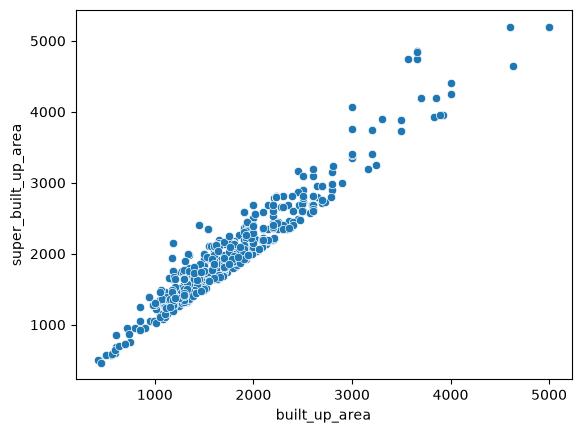

In [7]:
sns.scatterplot(data=df,x='built_up_area',y='super_built_up_area')

<Axes: xlabel='built_up_area', ylabel='carpet_area'>

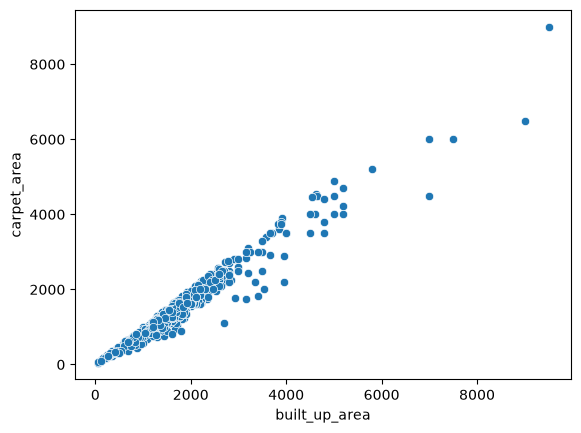

In [9]:
sns.scatterplot(data=df,x='built_up_area',y='carpet_area')

In [10]:
((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))

0       False
1       False
2       False
3       False
4       False
        ...  
3550    False
3551    False
3552    False
3553    False
3554    False
Length: 3555, dtype: bool

In [11]:
all_present_df = df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))]

In [12]:
all_present_df.shape

(531, 24)

In [13]:
super_to_built_up_ratio = (all_present_df['super_built_up_area']/all_present_df['built_up_area']).median()
carpet_to_built_up_ratio = (all_present_df['carpet_area']/all_present_df['built_up_area']).median()
print(super_to_built_up_ratio, carpet_to_built_up_ratio)

1.105263157894737 0.9


In [14]:
sbc_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [15]:
sbc_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
12,flat,shree vardhman flora,sector 90,0.92,4907.0,1875.0,Super Built up area 1875(174.19 sq.m.)Carpet a...,3,4,3,4.0,North-East,Relatively New,1875.0,NaN,1161.0,0,1,0,0,0,0,116,625.0
19,flat,signature global city 92,sector 92,0.78,11143.0,700.0,Super Built up area 1010(93.83 sq.m.)Carpet ar...,2,2,3,2.0,NaN,Under Construction,1010.0,NaN,700.0,0,0,0,0,1,0,24,350.0
22,flat,rof ananda,sector 95,0.55,8527.0,645.0,Super Built up area 1000(92.9 sq.m.)Carpet are...,3,2,2,14.0,East,New Property,1000.0,NaN,645.0,1,0,0,0,0,1,81,215.0
23,flat,alpha corp gurgaonone,sector 84,1.15,7497.0,1534.0,Super Built up area 1534(142.51 sq.m.)Carpet a...,2,2,3,14.0,South-East,Relatively New,1534.0,NaN,1260.0,1,0,0,0,0,0,28,767.0
44,flat,green court,sector 90,0.50,8333.0,600.0,Super Built up area 700(65.03 sq.m.)Carpet are...,2,2,1,8.0,NaN,New Property,700.0,NaN,600.0,0,0,0,0,0,0,42,300.0


In [17]:
sbc_df=sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2))

In [18]:
df.update(sbc_df)

In [19]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1011
agePossession             0
super_built_up_area    1680
built_up_area          1547
carpet_area            1715
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

In [20]:
sb_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())]

In [21]:
sb_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,flat,emaar mgf the palm drive,sector 66,3.98,18091.0,2200.0,Super Built up area 2200(204.39 sq.m.),3,4,3+,2.0,South-East,Moderately Old,2200.0,NaN,NaN,0,1,0,0,0,1,123,733.333333
2,flat,m3m heights,sector 65,2.44,13297.0,1835.0,Super Built up area 1828(169.83 sq.m.),3,3,2,7.0,NaN,Under Construction,1828.0,NaN,NaN,0,0,0,0,0,0,31,611.666667
4,flat,unitech the residences,sector 33,1.55,9873.0,1570.0,Super Built up area 1570(145.86 sq.m.),3,4,1,1.0,South,Relatively New,1570.0,NaN,NaN,0,1,0,0,0,0,37,523.333333
8,flat,chd avenue,sector 71,1.10,6104.0,1802.0,Super Built up area 1802(167.41 sq.m.),3,4,3,3.0,South,Moderately Old,1802.0,NaN,NaN,0,1,0,0,0,0,26,600.666667
10,flat,sare crescent parc royal greens phase 1,sector 92,0.79,6086.0,1298.0,Super Built up area 1298(120.59 sq.m.),3,2,2,15.0,NaN,New Property,1298.0,NaN,NaN,0,0,0,0,0,0,25,432.666667


In [22]:
sb_df=sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105))

In [23]:
df.update(sb_df)

In [24]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1011
agePossession             0
super_built_up_area    1680
built_up_area           672
carpet_area            1715
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

In [25]:
c_df = df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [26]:
c_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
1,flat,emaar digihomes,sector 62,2.15,14257.0,1508.0,Carpet area: 1508 (140.1 sq.m.),2,2,3,31.0,NaN,Under Construction,NaN,NaN,1508.0,0,0,0,0,0,0,101,754.000000
5,flat,smart world orchard,sector 61,2.54,15497.0,1639.0,Carpet area: 1640 (152.36 sq.m.),3,3,3,2.0,NaN,Under Construction,NaN,NaN,1640.0,0,0,1,0,0,0,16,546.333333
7,flat,signature global the millennia 3,sector 37d,0.45,7627.0,590.0,Carpet area: 590 (54.81 sq.m.),2,3,2,8.0,NaN,Under Construction,NaN,NaN,590.0,0,0,0,0,0,0,8,295.000000
9,flat,vatika gurgaon,sector 83,1.19,7438.0,1600.0,Carpet area: 1600 (148.64 sq.m.),3,3,2,10.0,South,Relatively New,NaN,NaN,1600.0,0,1,0,0,0,1,35,533.333333
13,flat,palam vihar society,sector 2,3.35,7444.0,4500.0,Carpet area: 4500 (418.06 sq.m.),4,4,3+,2.0,NaN,New Property,NaN,NaN,4500.0,1,0,0,0,0,0,66,1125.000000


In [27]:
c_df=c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9))

In [28]:
df.update(c_df)

In [30]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1011
agePossession             0
super_built_up_area    1680
built_up_area             0
carpet_area            1715
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

<Axes: xlabel='built_up_area', ylabel='price'>

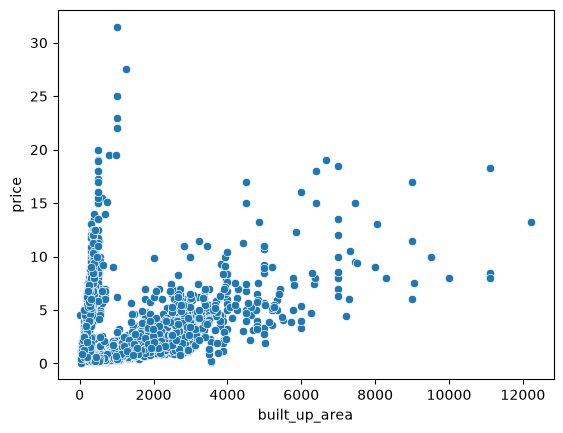

In [29]:
sns.scatterplot(data=df,x='built_up_area',y='price')

In [31]:
anomaly_df=df[(df['built_up_area']<2000) & (df['price']>2.5)][['price','area','built_up_area']]

In [32]:
anomaly_df['built_up_area']=anomaly_df['area']

In [33]:
df.update(anomaly_df)

<Axes: xlabel='built_up_area', ylabel='price'>

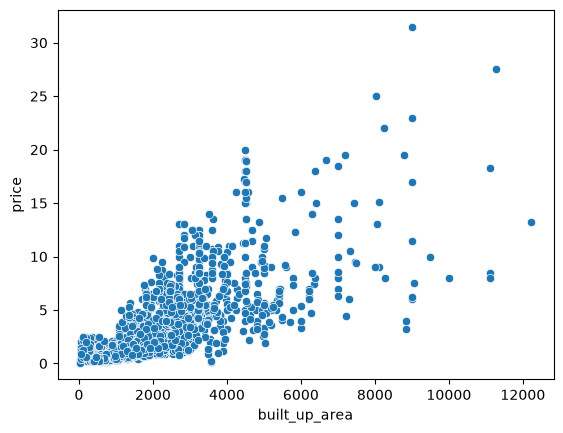

In [34]:
sns.scatterplot(data=df,x='built_up_area',y='price')

In [35]:
df.drop(columns=['area','areaWithType','super_built_up_area','carpet_area','area_room_ratio'],inplace=True)

In [36]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,emaar mgf the palm drive,sector 66,3.98,18091.0,3,4,3+,2.0,South-East,Moderately Old,2200.0,0,1,0,0,0,1,123
1,flat,emaar digihomes,sector 62,2.15,14257.0,2,2,3,31.0,NaN,Under Construction,1676.0,0,0,0,0,0,0,101
2,flat,m3m heights,sector 65,2.44,13297.0,3,3,2,7.0,NaN,Under Construction,1654.0,0,0,0,0,0,0,31
3,flat,the close south,sector 50,3.10,12445.0,3,4,3+,4.0,North-East,Moderately Old,2450.0,0,1,0,0,0,1,165
4,flat,unitech the residences,sector 33,1.55,9873.0,3,4,1,1.0,South,Relatively New,1421.0,0,1,0,0,0,0,37


In [37]:
df.isnull().sum()

property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
bedRoom               0
bathroom              0
balcony               0
floorNum             17
facing             1011
agePossession         0
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
furnishing_type       0
luxury_score          0
dtype: int64

In [38]:
df[df['floorNum'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
72,house,ansal sushant lok plots,sector 43,3.30,26570.0,1,1,0,NaN,NaN,Under Construction,1242.0,0,0,0,0,0,0,0
613,house,independent,sector 26,4.60,12198.0,4,4,3+,NaN,NaN,Old Property,3771.0,0,0,0,0,0,0,28
838,house,independent,sector 3,1.50,10288.0,3,3,0,NaN,NaN,Old Property,210.0,0,0,0,0,0,0,0
910,house,independent,sector 4,0.65,11111.0,4,2,2,NaN,NaN,Moderately Old,65.0,0,0,0,0,0,0,0
1212,house,emaar mgf marbella,sector 66,9.00,21251.0,4,4,3+,NaN,South-West,Relatively New,5200.0,0,1,1,1,0,1,114
1507,house,independent,sector 7,6.50,15046.0,3,2,3+,NaN,NaN,Old Property,4320.0,0,0,0,0,0,0,9
1529,house,independent,sector 25,13.00,45710.0,6,8,3+,NaN,NaN,Relatively New,2844.0,1,1,1,1,0,2,0
1982,flat,experion heartsong,dwarka expressway,1.08,6150.0,3,3,0,NaN,NaN,Under Construction,1758.0,0,0,0,0,0,0,0
2130,flat,NaN,sector 78,0.60,3692.0,2,2,0,NaN,NaN,Under Construction,1625.0,0,0,0,0,0,0,0
2209,house,ansal sushant lok,sector 43,10.50,27911.0,4,4,2,NaN,North-East,Old Property,3762.0,0,1,0,0,0,0,59


In [39]:
df[df['property_type']=='house']['floorNum'].median()

np.float64(2.0)

In [40]:
df['floorNum']=df['floorNum'].fillna(2.0)

In [41]:
df.isnull().sum()

property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
bedRoom               0
bathroom              0
balcony               0
floorNum              0
facing             1011
agePossession         0
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
furnishing_type       0
luxury_score          0
dtype: int64

<Axes: >

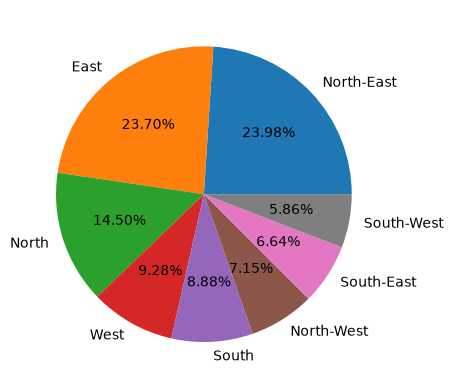

In [42]:
df['facing'].value_counts().plot(kind='pie',autopct='%0.2f%%')

In [43]:
df.drop(columns=['facing'],inplace=True)

In [44]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
594,flat,dlf new town heights,sector 86,1.30,6736.0,3,3,3,15.0,Relatively New,1715.0,0,1,0,1,0,1,49
2918,flat,conscient elevate,sector 59,3.90,16993.0,3,1,0,0.0,Undefined,2295.0,0,0,0,0,0,0,0
1813,flat,ats tourmaline,sector 109,1.40,8000.0,3,3,3+,5.0,Relatively New,1466.0,0,0,0,0,0,0,44
2846,flat,bptp terra,sector 37d,1.79,8981.0,4,3,3,15.0,Relatively New,1808.0,0,0,0,0,1,1,37
1176,flat,ashiana mulberry,sohna road,0.74,6198.0,2,2,3+,12.0,New Property,1344.0,0,0,0,0,0,0,67


In [46]:
df.isnull().sum()

property_type      0
society            1
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [47]:
df[df['society'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2130,flat,NaN,sector 78,0.6,3692.0,2,2,0,2.0,Under Construction,1625.0,0,0,0,0,0,0,0


In [48]:
df.drop(index=[2130],inplace=True)

In [49]:
df['agePossession'].value_counts()

agePossession
Relatively New        1605
New Property           557
Moderately Old         545
Old Property           293
Undefined              291
Under Construction     263
Name: count, dtype: int64

In [50]:
def mode_based_imputation(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector']) & (df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [51]:
df['agePossession']=df.apply(mode_based_imputation,axis=1)

In [52]:
df['agePossession'].value_counts()

agePossession
Relatively New        1718
New Property           596
Moderately Old         584
Old Property           325
Under Construction     277
Undefined               54
Name: count, dtype: int64

In [55]:
def mode_based_imputation2(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [56]:
df['agePossession']=df.apply(mode_based_imputation2,axis=1)

In [57]:
df['agePossession'].value_counts()

agePossession
Relatively New        1727
New Property           597
Moderately Old         591
Old Property           328
Under Construction     277
Undefined               34
Name: count, dtype: int64

In [58]:
def mode_based_imputation3(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [59]:
df['agePossession']=df.apply(mode_based_imputation3,axis=1)

In [60]:
df['agePossession'].value_counts()

agePossession
Relatively New        1729
Moderately Old         623
New Property           597
Old Property           328
Under Construction     277
Name: count, dtype: int64

In [61]:
df.isnull().sum()

property_type      0
society            0
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [62]:
df.to_csv('dataset/gurgaon_properties_missing_value_imputation.csv')